In [1]:
from pathlib import Path

dataset = Path("dataset")

for item in dataset.iterdir():
    print(item)

dataset\data.yaml
dataset\README.dataset.txt
dataset\README.roboflow.txt
dataset\test
dataset\train
dataset\valid


In [1]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
NVIDIA GeForce GTX 1070 Ti


(np.float64(-0.5), np.float64(479.5), np.float64(479.5), np.float64(-0.5))

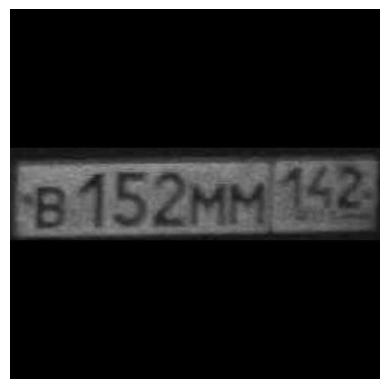

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("dataset/train/images/00-00-20-Cam1_jpg.rf.ada4ed9fb44cbf08360e167353f7c1ba.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

plt.axis("off")

(np.float64(-0.5), np.float64(479.5), np.float64(479.5), np.float64(-0.5))

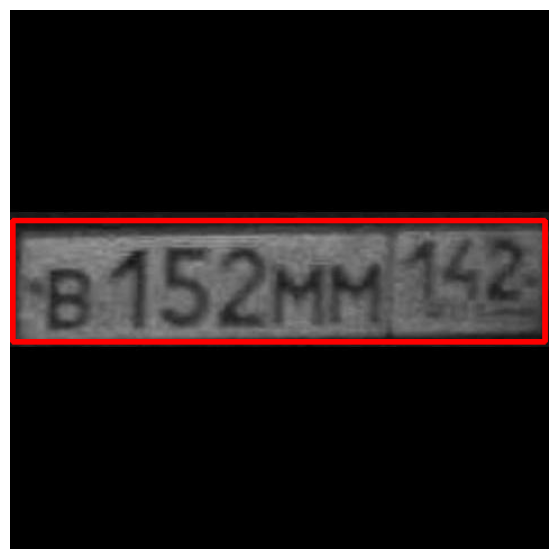

In [6]:
import cv2
import matplotlib.pyplot as plt

image_path = "dataset/train/images/00-00-20-Cam1_jpg.rf.ada4ed9fb44cbf08360e167353f7c1ba.jpg"
label_path = "dataset/train/labels/00-00-20-Cam1_jpg.rf.ada4ed9fb44cbf08360e167353f7c1ba.txt"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

with open(label_path) as f:

    for line in f:

        cls, xc, yc, bw, bh = map(float, line.split())

        x1 = int((xc-bw/2)*w)
        y1 = int((yc-bh/2)*h)

        x2 = int((xc+bw/2)*w)
        y2 = int((yc+bh/2)*h)

        cv2.rectangle(
            img,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            3
        )

plt.figure(figsize=(12,7))
plt.imshow(img)
plt.axis("off")

In [12]:
import sys
print(sys.executable)

C:\Users\lindo\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.81 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.80  Python-3.11.8 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1070 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000133AB95E890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [3]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/detect/train-3/weights/best.pt")

cap = cv2.VideoCapture(0)  # или видео файл

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    annotated = results[0].plot()

    cv2.imshow("ALPR", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 (no detections), 36.2ms
Speed: 60.8ms preprocess, 36.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [6]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-3/weights/best.pt")

results = model.predict(
    source="dataset/test/images/",
    conf=0.25,
    save=True
)


image 1/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\09-19-06-Cam1_jpg.rf.a794b758a807ec6ac08b6d2f82e0f175.jpg: 640x640 1 license-plate, 6.5ms
image 2/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\09-19-06-Cam2_jpg.rf.2110d0ac45022f2e9062bd320e03c1e1.jpg: 640x640 1 license-plate, 8.5ms
image 3/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\10_jpg.rf.1d44824ffb1234f63f3d2531593524d3.jpg: 480x640 5 license-plates, 9.5ms
image 4/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\11_6_2014_18_42_24_899_png.rf.8497e3135b77e92d28c28baea2923e5c.jpg: 480x640 1 license-plate, 6.5ms
image 5/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\11_jpg.rf.90f13ef3216a7240666417476e8aca65.jpg: 480x640 1 license-plate, 6.6ms
image 6/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\12_6_2014_19_54_57_849_png.rf.5f74991818bfb9bcb5b7ae9755b1b96d.jpg: 480x640 1 license-plate, 8.5ms
image 7/63 C:\Users\lindo\Downloads\ALPR-RU\dataset\test\images\15_jpg.rf.dcc0